# 03 — Exploratory data analysis

**Inputs:** `data/analysis_panel_wages.csv`
**Function:** describe the outcome, the predictors, and the wage block; produce the eight descriptive figures
**Outputs:** `output/figures/01`–`05`, `10_11` (two-panel wage figure), `12`; `output/tables/eda_*.csv`

FY2023 is a partial-year extract. It is kept in the descriptive time series, clearly
flagged, and excluded everywhere a model is fitted.

In [1]:
import sys
from pathlib import Path

# Locate the repository root by walking up until code/src is found, then put the
# code directory on the path. No absolute paths, so this runs from any checkout.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "code" / "src").is_dir())
sys.path.insert(0, str(_root / "code"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import (DATA, TABLES, MODEL_YEARS, finish, save,
                 C1, C2, SEQ, INK, INK2, SURFACE, describe_frame)

In [2]:
panel = pd.read_csv(DATA / "analysis_panel_wages.csv", low_memory=False)
describe_frame(panel, "joined analysis panel", keys=["key", "fy"])

eda = panel.copy()                                   # all years, descriptive only
fit_df = panel[panel.fy.isin(MODEL_YEARS)].copy()    # FY2017-FY2022, modelling window
matched = panel.lca_filings.notna()                  # rows carrying a wage block

print(f"\ndescriptive rows: {len(eda):,}")
print(f"modelling-window rows: {len(fit_df):,}")
print(f"rows with wage data: {matched.sum():,} ({matched.mean():.1%})")
print(f"model-window exact matches: {fit_df.lca_filings.notna().sum():,} "
      f"({fit_df.lca_filings.notna().mean():.1%})")

--- joined analysis panel ---
    rows: 176,404   columns: 38
    distinct key: 100,152
    distinct fy: 7
    columns with missing values: 13 (worst: share_low_level at 33.7%)

descriptive rows: 176,404
modelling-window rows: 165,593
rows with wage data: 119,185 (67.6%)
model-window exact matches: 119,185 (72.0%)


## 1. The outcome over time

This is the dominant fact in the dataset: close to an order of magnitude of movement in
six years, with initial and continuing petitions tracking each other at roughly 2:1. The
timing matches the *Buy American, Hire American* adjudication posture and its unwinding
after the 2020 *ITServe Alliance v. Cissna* settlement.

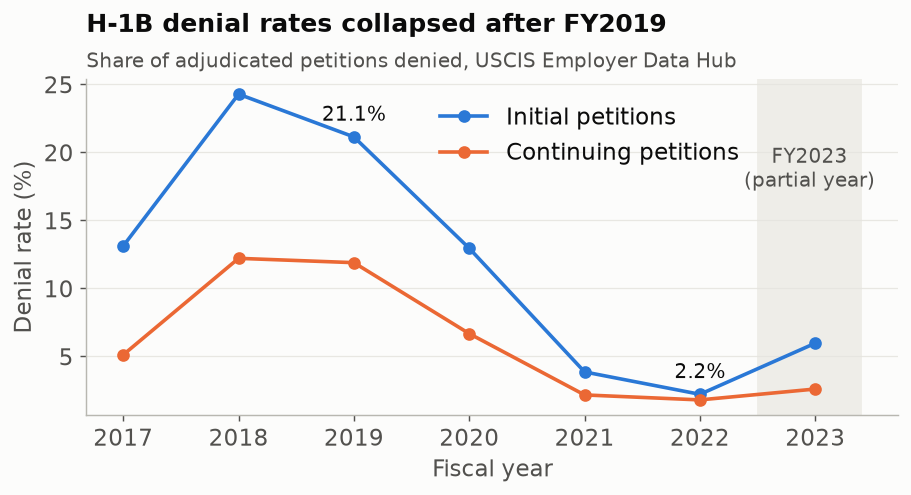

      initial_denial_rate  continuing_denial_rate
fy                                               
2017               0.1312                  0.0512
2018               0.2428                  0.1221
2019               0.2113                  0.1189
2020               0.1295                  0.0667
2021               0.0386                  0.0217
2022               0.0221                  0.0180
2023               0.0597                  0.0260


In [3]:
COUNTS = ["initial_approvals", "initial_denials",
          "continuing_approvals", "continuing_denials"]

yr = eda.groupby("fy")[COUNTS].sum()
yr["initial_denial_rate"] = yr.initial_denials / (yr.initial_approvals + yr.initial_denials)
yr["continuing_denial_rate"] = yr.continuing_denials / (
    yr.continuing_approvals + yr.continuing_denials)

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(yr.index, yr.initial_denial_rate * 100, color=C1, marker="o",
        markersize=6, label="Initial petitions")
ax.plot(yr.index, yr.continuing_denial_rate * 100, color=C2, marker="o",
        markersize=6, label="Continuing petitions")
for x in (2019, 2022):
    y = yr.loc[x, "initial_denial_rate"] * 100
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=11, color=INK)
ax.axvspan(2022.5, 2023.4, color="#eeede8", zorder=0)
ax.text(2022.95, yr.initial_denial_rate.max() * 100 * 0.72,
        "FY2023\n(partial year)", ha="center", fontsize=11, color=INK2)
ax.legend(loc="upper center", bbox_to_anchor=(0.62, 0.98))
finish(ax, "H-1B denial rates collapsed after FY2019",
       "Share of adjudicated petitions denied, USCIS Employer Data Hub",
       "Fiscal year", "Denial rate (%)")
save("01_denial_rate_timeseries")

yr.round(4).to_csv(TABLES / "eda_denial_rate_by_year.csv")
print(yr[["initial_denial_rate", "continuing_denial_rate"]].round(4).to_string())

## 2. Distributions of the continuous predictors

All three are log-scaled on the count axis. The left panel is the key one: the outcome
has enormous mass at exactly zero, which is what motivates fitting a binary classifier
alongside the continuous rate in `04_models`.

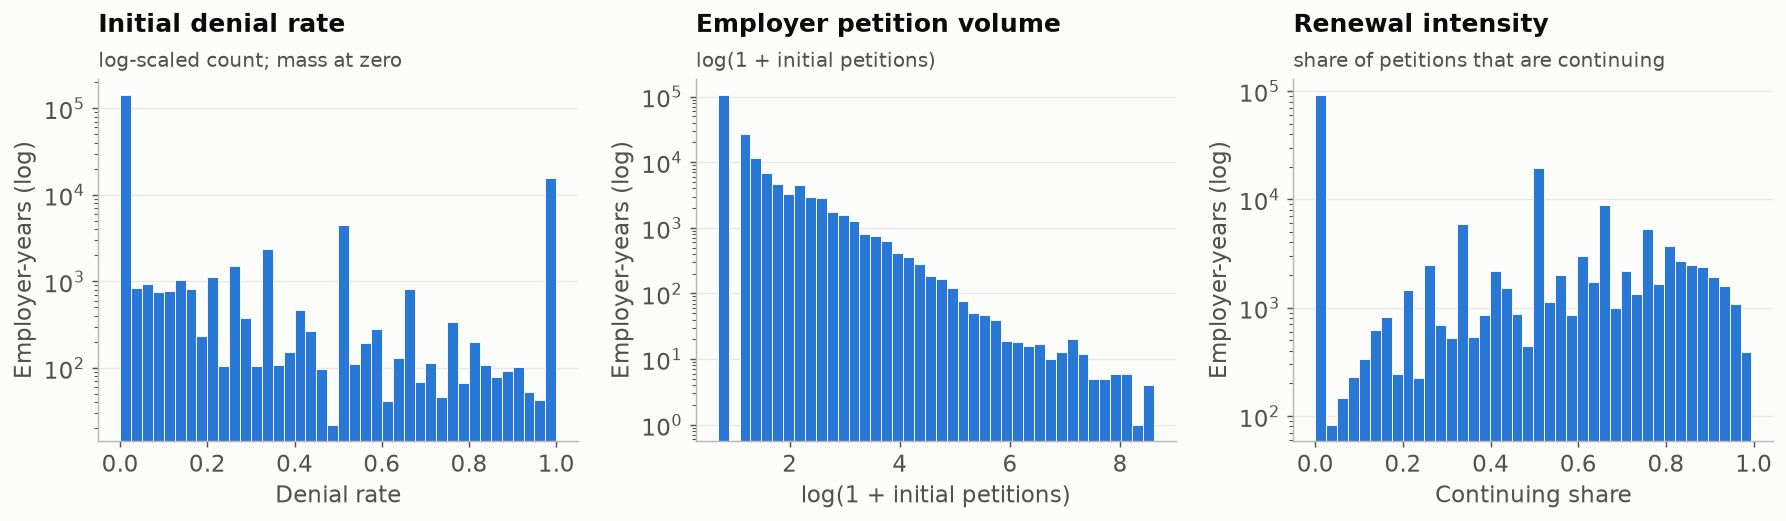

       denial_rate  log_initial  continuing_share  prev_denial_rate  prior_active_years
count   176404.000   176404.000        176404.000        176404.000          176404.000
mean         0.128        1.118             0.282             0.045               1.208
std          0.303        0.729             0.325             0.173               1.568
min          0.000        0.693             0.000             0.000               0.000
25%          0.000        0.693             0.000             0.000               0.000
50%          0.000        0.693             0.000             0.000               1.000
75%          0.000        1.386             0.553             0.000               2.000
max          1.000        8.613             0.995             1.000               6.000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].hist(eda.denial_rate, bins=40, color=SEQ, edgecolor=SURFACE, lw=0.5)
axes[0].set_yscale("log")
finish(axes[0], "Initial denial rate", "log-scaled count; mass at zero",
       "Denial rate", "Employer-years (log)")

axes[1].hist(eda.log_initial, bins=40, color=SEQ, edgecolor=SURFACE, lw=0.5)
axes[1].set_yscale("log")
finish(axes[1], "Employer petition volume", "log(1 + initial petitions)",
       "log(1 + initial petitions)", "Employer-years (log)")

axes[2].hist(eda.continuing_share, bins=40, color=SEQ, edgecolor=SURFACE, lw=0.5)
axes[2].set_yscale("log")
finish(axes[2], "Renewal intensity", "share of petitions that are continuing",
       "Continuing share", "Employer-years (log)")
save("02_histograms")

print(eda[["denial_rate", "log_initial", "continuing_share",
           "prev_denial_rate", "prior_active_years"]].describe().round(3).to_string())

## 3. Industry

Professional/scientific/technical services — where IT consulting sits — carries both the
plurality of petitions and by far the highest denial rate.

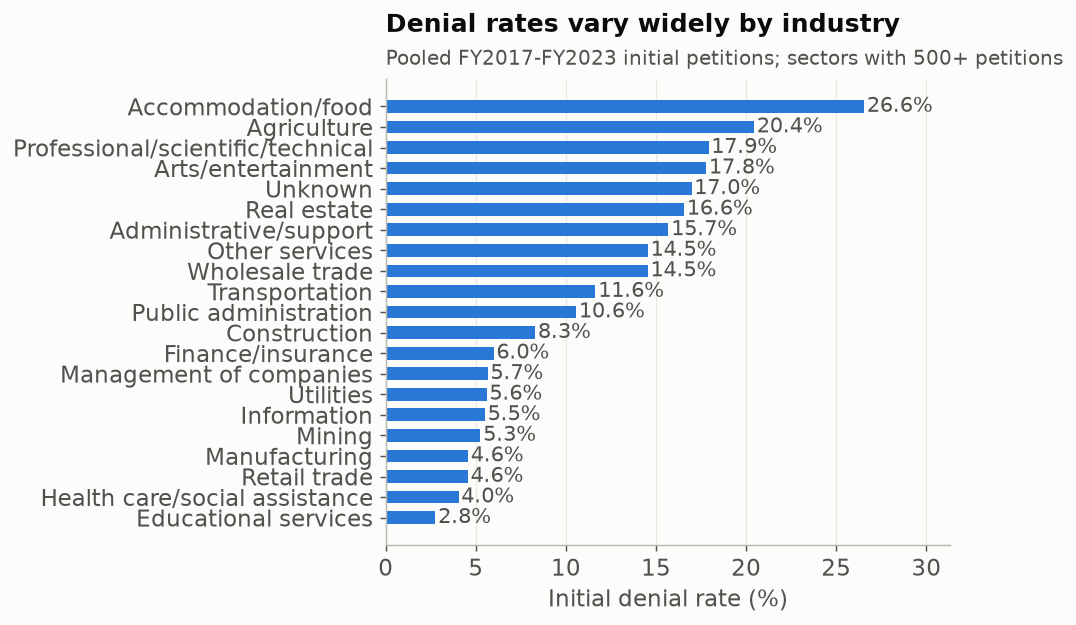

                                       n  initial  denials   rate
sector                                                           
Professional/scientific/technical  79930   481007    86171  17.91
Educational services               11540    82843     2287   2.76
Manufacturing                      19152    75487     3448   4.57
Information                         9308    51257     2821   5.50
Finance/insurance                  10236    42823     2565   5.99
Health care/social assistance      15593    41585     1681   4.04
Retail trade                        4130    38620     1760   4.56
Administrative/support              2574    10081     1582  15.69
Wholesale trade                     4691     8127     1182  14.54
Unknown                             4844     6570     1115  16.97
Construction                        3607     6002      498   8.30
Transportation                      1536     3539      412  11.64
Other services                      2119     3176      462  14.55
Real estat

In [5]:
sec = (eda.groupby("sector")
       .agg(n=("denial_rate", "size"),
            initial=("initial_total", "sum"),
            denials=("initial_denials", "sum"))
       .assign(rate=lambda t: t.denials / t.initial * 100)
       .query("initial >= 500").sort_values("rate"))

fig, ax = plt.subplots(figsize=(7.6, 5))
bars = ax.barh(sec.index, sec.rate, color=SEQ, height=0.62)
for b, v in zip(bars, sec.rate):
    ax.text(v + 0.15, b.get_y() + b.get_height() / 2, f"{v:.1f}%",
            va="center", fontsize=11.5, color=INK2)
ax.set_xlim(0, sec.rate.max() * 1.18)
finish(ax, "Denial rates vary widely by industry",
       "Pooled FY2017-FY2023 initial petitions; sectors with 500+ petitions",
       "Initial denial rate (%)", None, grid="x")
save("03_sector_bars")

sec.round(3).to_csv(TABLES / "eda_sector.csv")
print(sec.sort_values("initial", ascending=False).round(2).to_string())

## 4. Employer concentration

Mayda et al. (2020) document sponsorship concentrating in a narrow set of organisational
gatekeepers. That pattern is visible here directly.

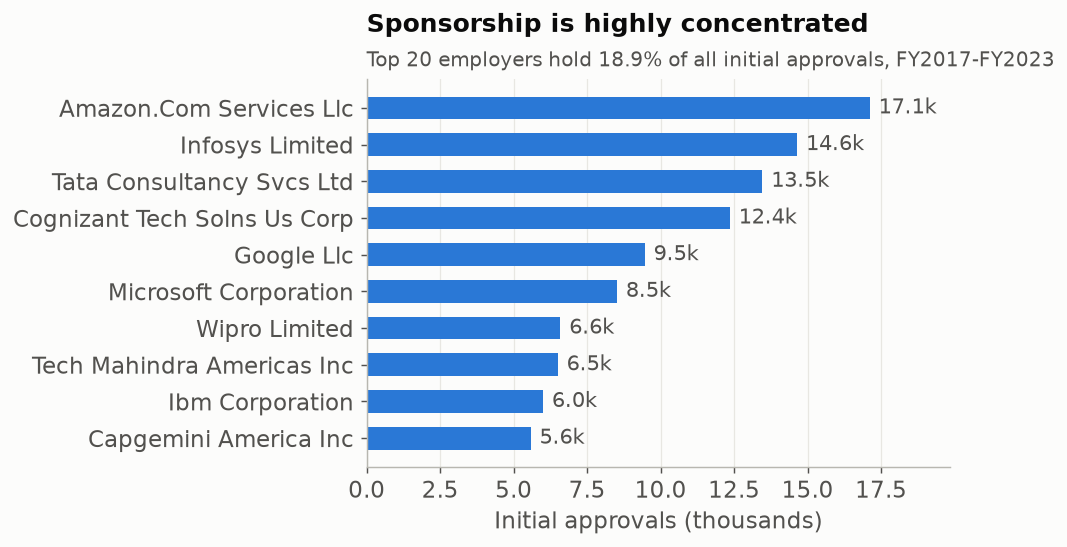

Top-20 employer share of initial approvals: 18.9%
                    employer  initial_approvals
     AMAZON.COM SERVICES LLC              17117
             INFOSYS LIMITED              14648
   TATA CONSULTANCY SVCS LTD              13465
COGNIZANT TECH SOLNS US CORP              12357
                  GOOGLE LLC               9462
       MICROSOFT CORPORATION               8519
               WIPRO LIMITED               6592
  TECH MAHINDRA AMERICAS INC               6503
             IBM CORPORATION               6003
       CAPGEMINI AMERICA INC               5582
             HCL AMERICA INC               5475
                FACEBOOK INC               5472
               ACCENTURE LLP               5386
                   APPLE INC               5327
           INTEL CORPORATION               5138
     DELOITTE CONSULTING LLP               4876
        ERNST & YOUNG US LLP               3431
     AMAZON WEB SERVICES INC               2846
           CISCO SYSTEMS INC          

In [6]:
top = eda.groupby("key").initial_approvals.sum().sort_values(ascending=False)
display_name = (eda.sort_values(["key", "initial_total"], ascending=[True, False])
                .drop_duplicates("key").set_index("key").employer)
share_top20 = top.head(20).sum() / top.sum() * 100

fig, ax = plt.subplots(figsize=(7.6, 4.4))
t10 = top.head(10).sort_values()
bars = ax.barh([display_name.get(k, k).title()[:34] for k in t10.index],
               t10.values / 1000,
               color=SEQ, height=0.62)
for b, v in zip(bars, t10.values / 1000):
    ax.text(v + 0.3, b.get_y() + b.get_height() / 2, f"{v:.1f}k",
            va="center", fontsize=11.5, color=INK2)
ax.set_xlim(0, (t10.values / 1000).max() * 1.16)
finish(ax, "Sponsorship is highly concentrated",
       f"Top 20 employers hold {share_top20:.1f}% of all initial approvals, FY2017-FY2023",
       "Initial approvals (thousands)", None, grid="x")
save("04_top_employers")

print(f"Top-20 employer share of initial approvals: {share_top20:.1f}%")
print(pd.DataFrame({"employer": display_name.reindex(top.head(20).index),
                    "initial_approvals": top.head(20)}).to_string(index=False))

## 5. Employer size

Petition volume and denial risk are related, but the association need not be monotonic.
The decile plot shows the observed shape without imposing a linear story.

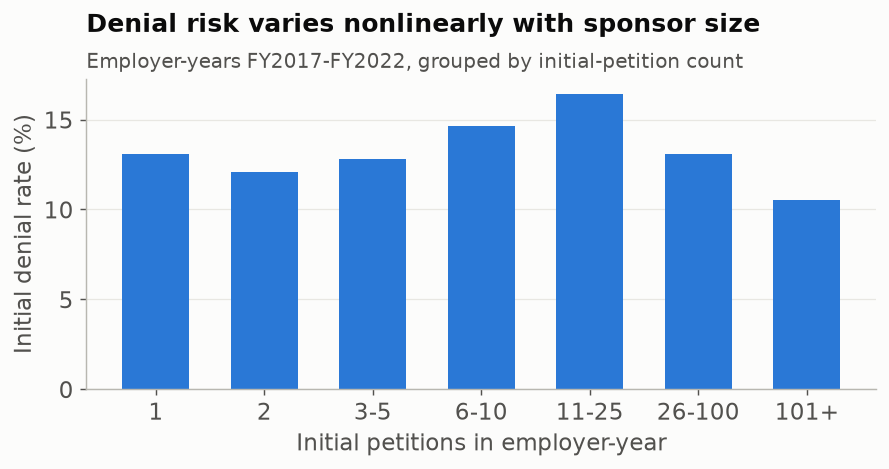

            rate  employer_years  initial_petitions
size_band                                          
1          13.09         98234.0            98234.0
2          12.11         25036.0            50072.0
3-5        12.80         21373.0            79174.0
6-10       14.63         10006.0            75641.0
11-25      16.45          7068.0           111903.0
26-100     13.07          3221.0           147197.0
101+       10.52           655.0           262677.0


In [7]:
SIZE_EDGES = [0, 1, 2, 5, 10, 25, 100, np.inf]
SIZE_LABELS = ["1", "2", "3-5", "6-10", "11-25", "26-100", "101+"]
fit_df["size_band"] = pd.cut(fit_df.initial_total, bins=SIZE_EDGES,
                             labels=SIZE_LABELS)
sz = fit_df.groupby("size_band", observed=True).apply(
    lambda t: pd.Series({
        "rate": t.initial_denials.sum() / t.initial_total.sum() * 100,
        "employer_years": len(t),
        "initial_petitions": t.initial_total.sum()}), include_groups=False)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(range(len(sz)), sz.rate, color=SEQ, width=0.62)
ax.set_xticks(range(len(sz)))
ax.set_xticklabels(sz.index)
finish(ax, "Denial risk varies nonlinearly with sponsor size",
       "Employer-years FY2017-FY2022, grouped by initial-petition count",
       "Initial petitions in employer-year", "Initial denial rate (%)")
save("05_size_band")

sz.round(3).to_csv(TABLES / "eda_size_band.csv")
print(sz.round(2).to_string())

## 6. The wage block

Everything below uses exact employer-year matches only. The percentage is computed in
the executed cell rather than hardcoded; see `02_merge` for who fails to match and why.

### 6.1 Offered wage relative to prevailing wage

Statistics are computed here; the histogram is drawn as the left panel of the two-panel figure in 6.2 so the inline backend does not close it between cells.

In [8]:
wage_df = panel
wr_raw = wage_df.loc[matched, "wage_ratio_med"].dropna()
at_prevailing = (wr_raw <= 1.0001).mean() * 100
wr = wr_raw.clip(upper=1.8)

print(f"Median employer-year wage ratio: {wr_raw.median():.3f}")
print(f"Share at or below the prevailing wage: {at_prevailing:.1f}%")


Median employer-year wage ratio: 1.036
Share at or below the prevailing wage: 27.8%


### 6.2 Prevailing-wage level mix

Costa and Hira (2020) report that 60% of FY2019 certified positions used the two lowest
prevailing wage levels. Position-weighted, this panel puts the figure higher still, and
it is stable across the whole period rather than a feature of one year.

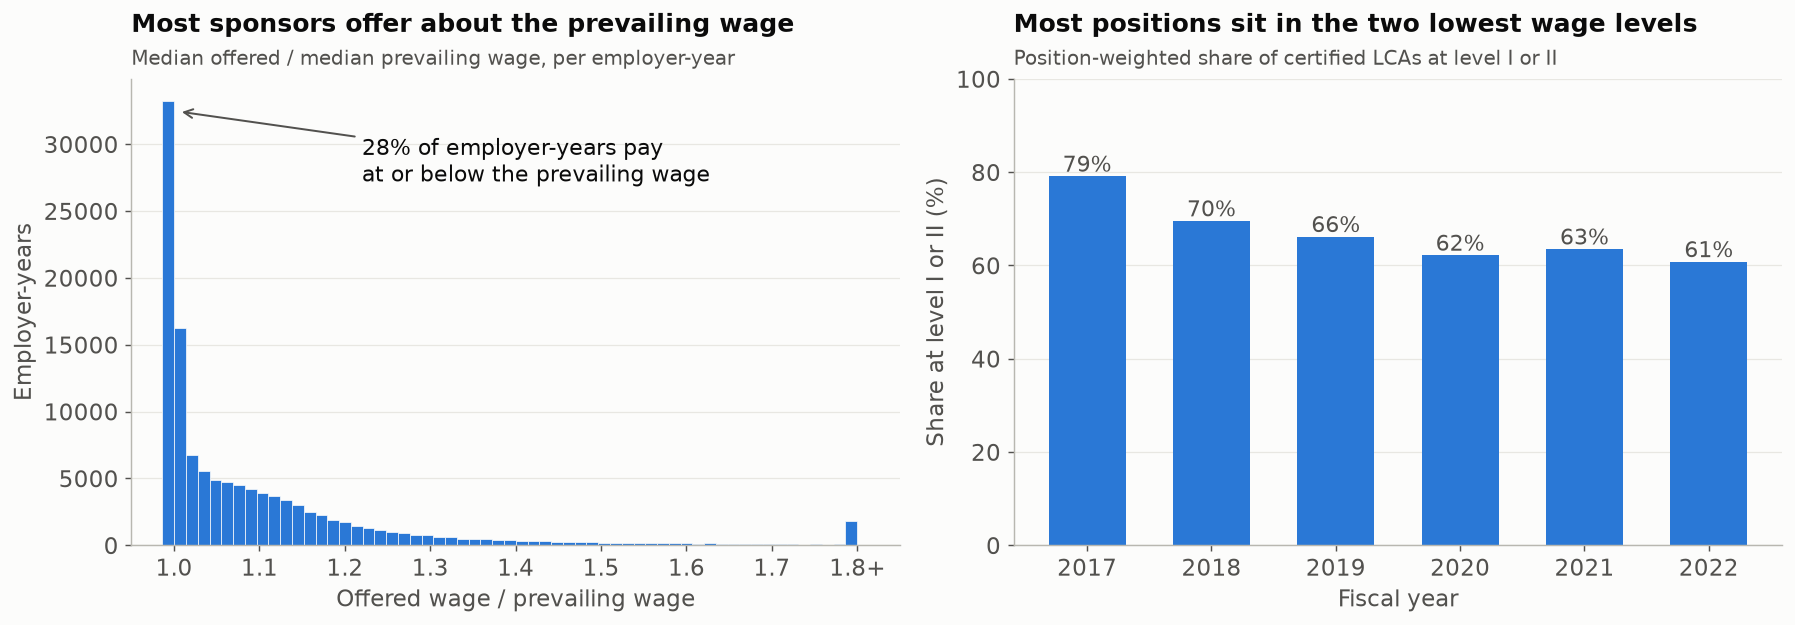

fy
2017    79.1
2018    69.5
2019    66.1
2020    62.1
2021    63.5
2022    60.8


In [9]:
byyr = (wage_df[matched].groupby("fy")
        .apply(lambda t: t.low_level_positions.sum()
                         / t.known_level_positions.sum() * 100,
               include_groups=False))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: offered wage / prevailing wage
ax.hist(wr, bins=64, color=SEQ, edgecolor=SURFACE, lw=0.4)
ax.annotate(f"{at_prevailing:.0f}% of employer-years pay\nat or below the prevailing wage",
            xy=(1.005, ax.get_ylim()[1] * 0.93),
            xytext=(1.22, ax.get_ylim()[1] * 0.78),
            fontsize=12, color=INK,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=1.1))
ax.set_xlim(0.95, 1.85)
ax.set_xticks([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8])
ax.set_xticklabels(["1.0", "1.1", "1.2", "1.3", "1.4", "1.5", "1.6", "1.7", "1.8+"])
finish(ax, "Most sponsors offer about the prevailing wage",
       "Median offered / median prevailing wage, per employer-year",
       "Offered wage / prevailing wage", "Employer-years")

# Right panel: share of positions at wage level I or II
ax2.bar(byyr.index, byyr.values, color=SEQ, width=0.62)
for x, v in zip(byyr.index, byyr.values):
    ax2.text(x, v + 1, f"{v:.0f}%", ha="center", fontsize=12, color=INK2)
ax2.set_ylim(0, 100)
finish(ax2, "Most positions sit in the two lowest wage levels",
       "Position-weighted share of certified LCAs at level I or II",
       "Fiscal year", "Share at level I or II (%)")
save("10_11_wage_panels")

byyr.round(1).to_csv(TABLES / "eda_wage_level_share.csv")
print(byyr.round(1).to_string())


### 6.3 Denial rate by wage band

A quarter of employer-years sit at a ratio of exactly 1.000, so rank-based deciles would
split that tie arbitrarily. Explicit bands are used instead. Only three employer-years
fall below 1.00, so they fold into the "at prevailing" band rather than forming a bar of
their own.

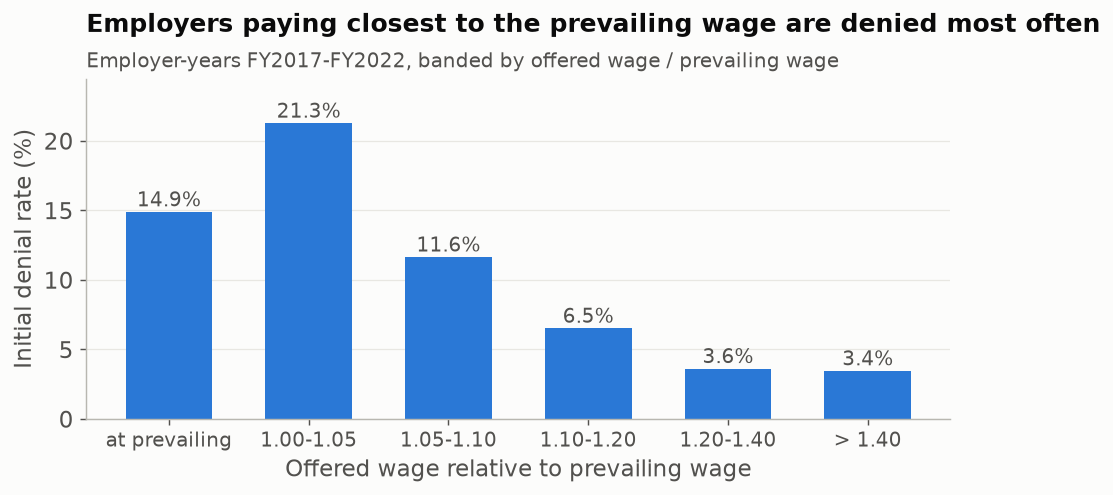

                 rate  employer_years
wr_band                              
at prevailing  14.883         33009.0
1.00-1.05      21.261         31689.0
1.05-1.10      11.633         16263.0
1.10-1.20       6.511         20519.0
1.20-1.40       3.609         11526.0
> 1.40          3.448          5933.0


In [10]:
m = wage_df[matched & wage_df.wage_ratio_med.notna()].copy()
EDGES = [0, 1.0001, 1.05, 1.10, 1.20, 1.40, np.inf]
LABELS = ["at prevailing", "1.00-1.05", "1.05-1.10",
          "1.10-1.20", "1.20-1.40", "> 1.40"]
m["wr_band"] = pd.cut(m.wage_ratio_med, bins=EDGES, labels=LABELS, include_lowest=True)

wd = m.groupby("wr_band", observed=True).apply(
    lambda t: pd.Series({
        "rate": t.initial_denials.sum() / t.initial_total.sum() * 100,
        "employer_years": len(t)}), include_groups=False)

fig, ax = plt.subplots(figsize=(7.6, 4))
ax.bar(range(len(wd)), wd.rate, color=SEQ, width=0.62)
for i, v in enumerate(wd.rate):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=11, color=INK2)
ax.set_xticks(range(len(wd)))
ax.set_xticklabels(wd.index, fontsize=11)
ax.set_ylim(0, wd.rate.max() * 1.15)
finish(ax, "Employers paying closest to the prevailing wage are denied most often",
       "Employer-years FY2017-FY2022, banded by offered wage / prevailing wage",
       "Offered wage relative to prevailing wage", "Initial denial rate (%)")
save("12_denial_by_wage_band")

wd.round(3).to_csv(TABLES / "eda_denial_by_wage_band.csv")
print(wd.round(3).to_string())

This is a descriptive association, not a causal claim: employers who pay at the floor are
disproportionately the small, IT-staffing-style petitioners who also attract the most
adjudicator scrutiny. `04_models` tests whether the wage block still adds predictive
signal once size, history, sector and year are controlled for.

**Next:** `04_models.ipynb`.